# SAM40 EEG Mental Task Classification
### A clean, end-to-end pipeline: Load → Preprocess → Epoch → Features → Train → Evaluate → Tune

**Dataset:** SAM40 (4 tasks: Arithmetic, Mirror, Relax, Stroop)  
**Validation:** Subject-wise split · 5-Fold CV · 10-Fold CV · LOSO  
**Models:** SVM (Linear), SVM (RBF), KNN, Random Forest, MLP, Gradient Boosting, XGBoost


---
## 1 · Environment Setup & Configuration

In [21]:
#!pip install -q scikit-learn matplotlib seaborn scipy scikit-image xgboost joblib

import os, glob, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.io as sio
import scipy.signal as sig
from scipy.stats import skew, kurtosis
from joblib import Parallel, delayed

from sklearn.preprocessing    import StandardScaler, label_binarize
from sklearn.model_selection  import (StratifiedKFold, LeaveOneGroupOut,
                                       GridSearchCV, cross_val_score)
from sklearn.impute            import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline          import Pipeline
from sklearn.svm               import SVC
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.ensemble          import (RandomForestClassifier,
                                        GradientBoostingClassifier)
from sklearn.neural_network    import MLPClassifier
from sklearn.metrics           import (accuracy_score, precision_score,
                                        recall_score, f1_score,
                                        confusion_matrix)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not found — skipping it")

warnings.filterwarnings('ignore')

# ── Global constants ───────────────────────────────────────────────────────────
SEED        = 42
FS          = 128          # sampling rate (Hz)
EPOCH_SEC   = 4            # epoch length in seconds
EPOCH_LEN   = FS * EPOCH_SEC   # 512 samples
N_FEATURES  = 150          # top-k features kept by SelectKBest
N_TASKS     = 4
TASK_NAMES  = ['Arithmetic', 'Mirror', 'Relax', 'Stroop']
TASK_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
TASK_MAP    = {'arithmetic': 0, 'mirror': 1, 'relax': 2, 'stroop': 3}

np.random.seed(SEED)
print("✅ Environment ready")


✅ Environment ready


---
## 2 · Dataset Loading

> **Edit `DATASET_DIR`** to point to your extracted SAM40 folder.

In [ ]:
# ── Set your dataset path here ─────────────────────────────────────────────────
DATASET_DIR = r"C:\Users\AP HAMESH\OneDrive\Desktop\AP\MIND\sam40\Data\SAM40\filtered_data"
assert os.path.exists(DATASET_DIR), f"❌ Not found: {DATASET_DIR}"

RAW_DIR = os.path.join(DATASET_DIR, 'Data', 'raw_data')
if not os.path.exists(RAW_DIR):
    RAW_DIR = DATASET_DIR
print(f"Loading .mat files from: {RAW_DIR}")
#data loading happens here:
def load_mat(fpath):
    """Load EEG matrix from a .mat file. Returns (samples × channels) or None."""
    mat  = sio.loadmat(fpath)
    keys = [k for k in mat if not k.startswith('_')]
    for k in ['data', 'eegData', 'EEG', 'eeg'] + keys:
        if k in mat:
            d = mat[k].astype(np.float32)
            return d.T if d.shape[0] < d.shape[1] else d
    return None

mat_files = sorted(glob.glob(os.path.join(RAW_DIR, '**', '*.mat'), recursive=True))
print(f"Found {len(mat_files)} .mat files")

X_raw, y_raw, subj_raw = [], [], []
for fpath in mat_files:
    fname = os.path.basename(fpath).lower()
    label = next((lbl for key, lbl in TASK_MAP.items() if key in fname), None)
    if label is None:
        continue
    nums = re.findall(r'\d+', fname)
    subj = int(nums[0]) if nums else 0
    try:
        data = load_mat(fpath)
        if data is not None and data.shape[0] > 50:
            X_raw.append(data)
            y_raw.append(label)
            subj_raw.append(subj)
    except Exception:
        pass

X_raw    = np.array(X_raw, dtype=object)
y_raw    = np.array(y_raw)
subj_raw = np.array(subj_raw)

print(f"\n✅ Loaded {len(X_raw)} signals | {len(np.unique(subj_raw))} subjects")
for i, name in enumerate(TASK_NAMES):
    print(f"   {name}: {(y_raw == i).sum()} signals")
print(f"   Signal shape (example): {X_raw[0].shape}  (samples × channels)")


Loading .mat files from: C:\Users\AP HAMESH\OneDrive\Desktop\AP\MIND\sam40\Data\SAM40\filtered_data
Found 480 .mat files

✅ Loaded 480 signals | 40 subjects
   Arithmetic: 120 signals
   Mirror: 120 signals
   Relax: 120 signals
   Stroop: 120 signals
   Signal shape (example): (3200, 32)  (samples × channels)


---
## 3 · Preprocessing

Three steps applied in order:
1. **Bandpass filter** 0.5–45 Hz — removes DC drift and high-frequency noise
2. **Notch filter** at 50 Hz — removes power-line interference
3. **Z-score normalization** — makes channels comparable across subjects

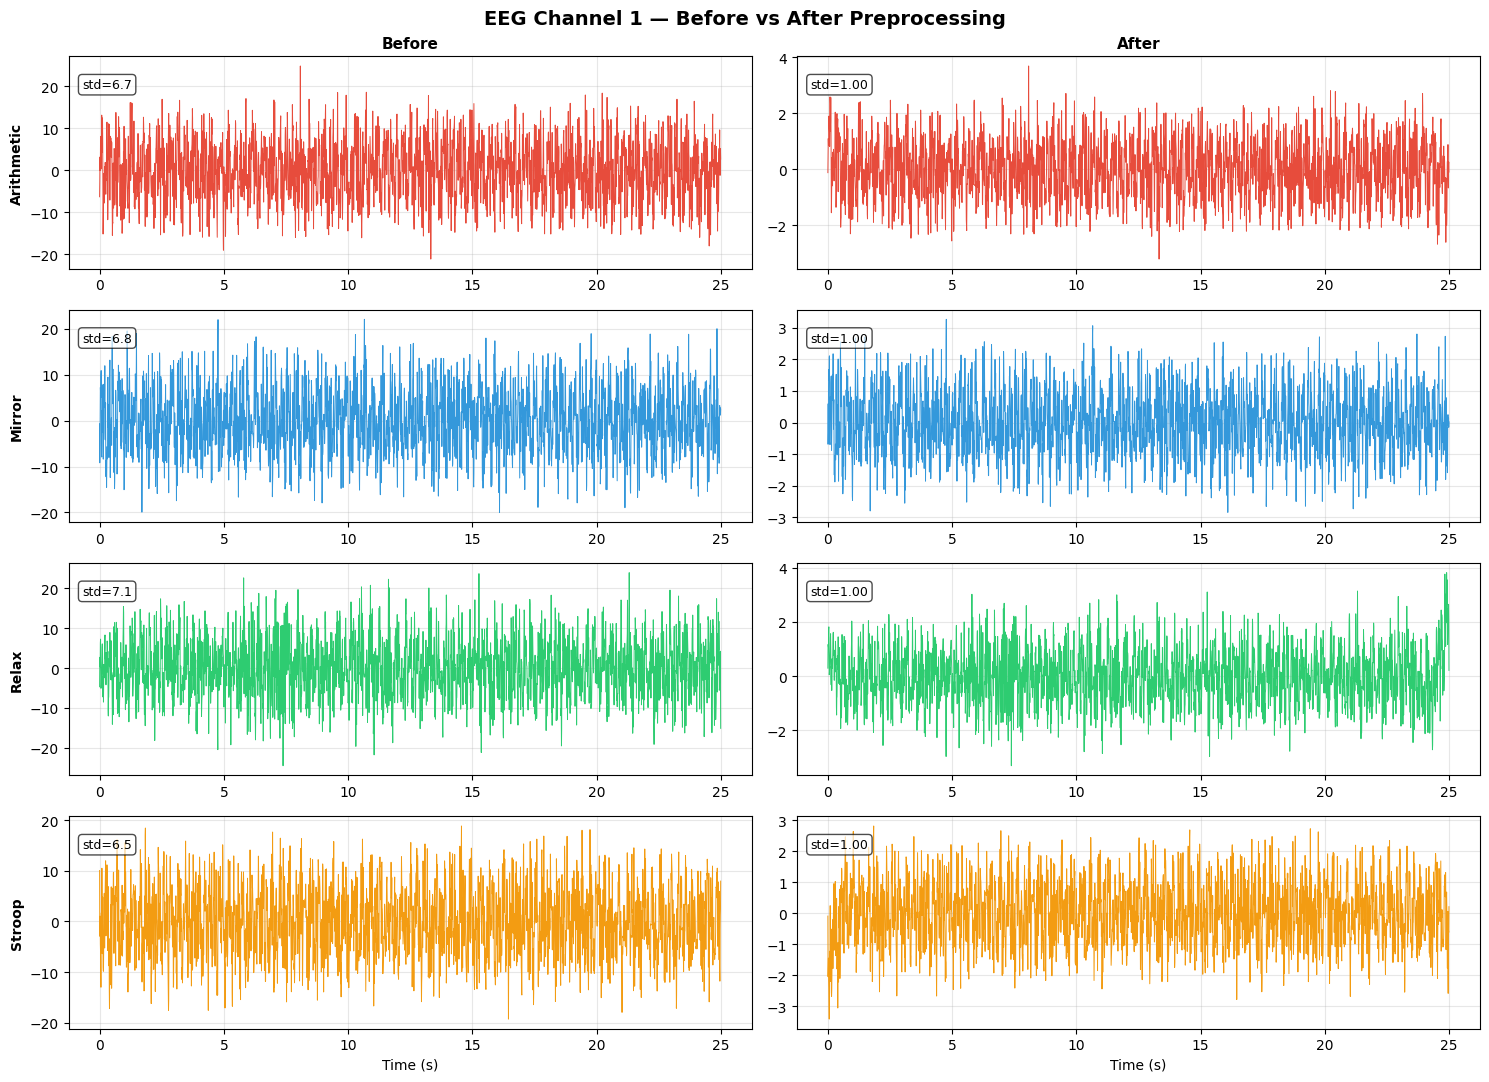

✅ Preprocessing visualization saved


In [23]:
def bandpass(data, lo=0.5, hi=45.0, fs=FS, order=4):
    data = np.asarray(data, dtype=np.float64)
    nyq  = fs / 2.0
    b, a = sig.butter(order, [lo / nyq, hi / nyq], btype='band')
    return sig.filtfilt(b, a, data, axis=0)

def notch_filter(data, freq=50.0, fs=FS, Q=30):
    b, a = sig.iirnotch(freq / (fs / 2.0), Q)
    return sig.filtfilt(b, a, data, axis=0)

def znorm(data):
    mu  = data.mean(axis=0, keepdims=True)
    std = data.std(axis=0,  keepdims=True) + 1e-8
    return (data - mu) / std

def preprocess(data):
    """Full preprocessing pipeline: bandpass → notch → z-normalize."""
    return znorm(notch_filter(bandpass(data)))

# ── Quick visual: Before vs After (channel 1, one signal per task) ─────────────
fig, axes = plt.subplots(N_TASKS, 2, figsize=(15, 11))
fig.suptitle('EEG Channel 1 — Before vs After Preprocessing', fontsize=14, fontweight='bold')

for i, (name, color) in enumerate(zip(TASK_NAMES, TASK_COLORS)):
    idx   = np.where(y_raw == i)[0][0]
    raw   = X_raw[idx][:, 0]
    clean = preprocess(X_raw[idx])[:, 0]
    t     = np.arange(len(raw)) / FS

    axes[i, 0].plot(t, raw,   color=color, lw=0.7)
    axes[i, 0].set_ylabel(name, fontsize=10, fontweight='bold')
    axes[i, 0].set_title('Before' if i == 0 else '', fontsize=11, fontweight='bold')
    axes[i, 0].grid(alpha=0.3)
    axes[i, 0].annotate(f'std={raw.std():.1f}', xy=(0.02, 0.85),
                         xycoords='axes fraction', fontsize=9,
                         bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    axes[i, 1].plot(t[:len(clean)], clean, color=color, lw=0.7)
    axes[i, 1].set_title('After' if i == 0 else '', fontsize=11, fontweight='bold')
    axes[i, 1].grid(alpha=0.3)
    axes[i, 1].annotate(f'std={clean.std():.2f}', xy=(0.02, 0.85),
                         xycoords='axes fraction', fontsize=9,
                         bbox=dict(boxstyle='round', fc='white', alpha=0.7))

for ax in axes[-1]:
    ax.set_xlabel('Time (s)', fontsize=10)
plt.tight_layout()
plt.savefig('before_after_preprocessing.png', dpi=110, bbox_inches='tight')
plt.show()
print("✅ Preprocessing visualization saved")


---
## 4 · Epoching

Non-overlapping 4-second windows (512 samples). Each epoch gets the same label and subject ID as its parent signal.

In [24]:
def make_epochs(data, length=EPOCH_LEN):
    """Slice cleaned signal into non-overlapping windows."""
    return [data[s : s + length]
            for s in range(0, data.shape[0] - length + 1, length)]

print("Preprocessing and epoching all signals …")
X_epochs, y_epochs, subj_epochs = [], [], []

for data, label, subj in zip(X_raw, y_raw, subj_raw):
    cleaned = preprocess(data)
    for ep in make_epochs(cleaned):
        X_epochs.append(ep)
        y_epochs.append(label)
        subj_epochs.append(subj)

X_epochs    = np.array(X_epochs)
y_epochs    = np.array(y_epochs)
subj_epochs = np.array(subj_epochs)

print(f"✅ Total epochs : {len(X_epochs)}")
print(f"   Shape        : {X_epochs[0].shape}  ({EPOCH_SEC}s × {X_epochs[0].shape[1]} channels)")
for i, name in enumerate(TASK_NAMES):
    print(f"   {name}: {(y_epochs == i).sum()} epochs")


Preprocessing and epoching all signals …
✅ Total epochs : 2880
   Shape        : (512, 32)  (4s × 32 channels)
   Arithmetic: 720 epochs
   Mirror: 720 epochs
   Relax: 720 epochs
   Stroop: 720 epochs


TORCH INSTALLATION

In [25]:
!pip install torch torchvision torchaudio

EEGNET

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EEGNet(nn.Module):
    def __init__(self, n_channels=32, time_steps=512, n_classes=4, 
                 F1=8, D=2, F2=16, kernel_length=64, dropout_rate=0.5):
        super(EEGNet, self).__init__()
        
        # ---------------------------------------------------------------------
        # BLOCK 1: Temporal & Spatial Convolutions
        # ---------------------------------------------------------------------
        # 1a. Temporal Convolution: Extracts frequency features over time
        self.temporal_conv = nn.Conv2d(
            in_channels=1, 
            out_channels=F1, 
            kernel_size=(1, kernel_length), 
            padding=(0, kernel_length // 2), 
            bias=False
        )
        self.batch_norm1 = nn.BatchNorm2d(F1)
        
        # 1b. Spatial (Depthwise) Convolution: Learns patterns across channels
        self.spatial_conv = nn.Conv2d(
            in_channels=F1, 
            out_channels=F1 * D, 
            kernel_size=(n_channels, 1), 
            groups=F1, 
            bias=False
        )
        self.batch_norm2 = nn.BatchNorm2d(F1 * D)
        self.pooling1 = nn.AvgPool2d(kernel_size=(1, 4))
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # ---------------------------------------------------------------------
        # BLOCK 2: Separable Convolution (Temporal + Pointwise)
        # ---------------------------------------------------------------------
        self.separable_conv = nn.Conv2d(
            in_channels=F1 * D, 
            out_channels=F2, 
            kernel_size=(1, 16), 
            padding=(0, 8), 
            groups=F2, 
            bias=False
        )
        self.project_conv = nn.Conv2d(
            in_channels=F2, 
            out_channels=F2, 
            kernel_size=(1, 1), 
            bias=False
        )
        self.batch_norm3 = nn.BatchNorm2d(F2)
        self.pooling2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # ---------------------------------------------------------------------
        # BLOCK 3: Classification Layer
        # ---------------------------------------------------------------------
        flat_features = F2 * (time_steps // 4 // 8) # For 512 steps: 16 * 16 = 256
        self.classifier = nn.Linear(flat_features, n_classes)
        
    def forward(self, x):
        # Block 1 execution
        x = self.temporal_conv(x)
        x = self.batch_norm1(x)
        x = self.spatial_conv(x)
        x = self.batch_norm2(x)
        x = F.elu(x)
        x = self.pooling1(x)
        x = self.dropout1(x)
        
        # Block 2 execution
        x = self.separable_conv(x)
        x = self.project_conv(x)
        x = self.batch_norm3(x)
        x = F.elu(x)
        x = self.pooling2(x)
        x = self.dropout2(x)
        
        # Flatten and Classify
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

print("✅ EEGNet architecture class successfully added!")

✅ EEGNet architecture class successfully added!


In [27]:
# Reshape existing epochs from (N, 512, 32) → (N, 32, 512) for EEGNet
X_epochs_eegnet = np.transpose(X_epochs, (0, 2, 1))   # (N, 32, 512)
y_epochs_eegnet = y_epochs.copy()
subj_epochs_eegnet = subj_epochs.copy()
print("EEGNet-ready shape:", X_epochs_eegnet.shape)   # (num_epochs, 32, 512)

EEGNet-ready shape: (2880, 32, 512)


 Add per-epoch normalization 

In [28]:
def normalize_epochs(X):
    """Per-epoch, per-channel z-score normalization. X: (N, C, T)"""
    mu = X.mean(axis=2, keepdims=True)
    sigma = X.std(axis=2, keepdims=True) + 1e-8
    return (X - mu) / sigma

X_epochs_eegnet = normalize_epochs(X_epochs_eegnet)
print("✅ Per-epoch normalization applied:", X_epochs_eegnet.mean(), X_epochs_eegnet.std())

✅ Per-epoch normalization applied: -6.52027139841977e-20 0.9999999899379516


Increase model capacity slightly + tune dropout against your overfitting signal

In [29]:
# slightly larger temporal filter bank, a touch more dropout
model = EEGNet(n_channels=32, time_steps=512, n_classes=4,F1=16, D=2, F2=32, kernel_length=64, dropout_rate=0.6)

Add light data augmentation — biggest expected payoff for the lowest code cost

In [30]:
def augment_epoch(epoch, noise_std=0.05, max_shift=20):
    """epoch: (C, T). Light Gaussian noise + circular time-shift jitter."""
    aug = epoch.copy()
    aug += np.random.normal(0, noise_std, aug.shape)
    shift = np.random.randint(-max_shift, max_shift + 1)
    aug = np.roll(aug, shift, axis=1)
    return aug

class EEGDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X_raw = X  # keep raw numpy, augment per __getitem__ call if training
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X_raw[idx]
        if self.augment:
            x = augment_epoch(x)
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # (1, C, T)
        return x, self.y[idx]

Then in train_eegnet

In [32]:
X_epochs_eegnet = np.transpose(X_epochs, (0, 2, 1))
y_epochs_eegnet = y_epochs.copy()
subj_epochs_eegnet = subj_epochs.copy()
X_epochs_eegnet = normalize_epochs(X_epochs_eegnet)   # NEW — per-epoch z-score normalization
print("EEGNet-ready shape:", X_epochs_eegnet.shape)

EEGNet-ready shape: (2880, 32, 512)


 Dataset wrapper + training function

In [33]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class EEGNet(nn.Module):
    def __init__(self, n_channels=32, time_steps=512, n_classes=4,
                 F1=16, D=2, F2=32, kernel_length=64, dropout_rate=0.6):
        super(EEGNet, self).__init__()
        self.temporal_conv = nn.Conv2d(1, F1, (1, kernel_length), padding=(0, kernel_length // 2), bias=False)
        self.batch_norm1 = nn.BatchNorm2d(F1)
        self.spatial_conv = nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False)
        self.batch_norm2 = nn.BatchNorm2d(F1 * D)
        self.pooling1 = nn.AvgPool2d((1, 4))
        self.dropout1 = nn.Dropout(dropout_rate)
        self.separable_conv = nn.Conv2d(F1 * D, F2, (1, 16), padding=(0, 8),
                                         groups=F2 if F1 * D == F2 else 1, bias=False)
        self.project_conv = nn.Conv2d(F2, F2, (1, 1), bias=False)
        self.batch_norm3 = nn.BatchNorm2d(F2)
        self.pooling2 = nn.AvgPool2d((1, 8))
        self.dropout2 = nn.Dropout(dropout_rate)
        flat_features = F2 * (time_steps // 4 // 8)
        self.classifier = nn.Linear(flat_features, n_classes)

    def forward(self, x):
        x = self.temporal_conv(x)
        x = self.batch_norm1(x)
        x = self.spatial_conv(x)
        x = self.batch_norm2(x)
        x = F.elu(x)
        x = self.pooling1(x)
        x = self.dropout1(x)
        x = self.separable_conv(x)
        x = self.project_conv(x)
        x = self.batch_norm3(x)
        x = F.elu(x)
        x = self.pooling2(x)
        x = self.dropout2(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


def normalize_epochs(X):
    """Per-epoch, per-channel z-score normalization. X: (N, C, T)"""
    mu = X.mean(axis=2, keepdims=True)
    sigma = X.std(axis=2, keepdims=True) + 1e-8
    return (X - mu) / sigma


def augment_epoch(epoch, noise_std=0.05, max_shift=20):
    """epoch: (C, T). Light Gaussian noise + circular time-shift jitter."""
    aug = epoch.copy()
    aug = aug + np.random.normal(0, noise_std, aug.shape)
    shift = np.random.randint(-max_shift, max_shift + 1)
    aug = np.roll(aug, shift, axis=1)
    return aug


class EEGDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X_raw = X
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X_raw[idx]
        if self.augment:
            x = augment_epoch(x)
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
        return x, self.y[idx]


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


def train_eegnet(X_train, y_train, X_val, y_val, n_classes=4,
                  n_channels=32, time_steps=512,
                  epochs=60, batch_size=32, lr=1e-3, patience=10,
                  use_augment=True, verbose=True):
    train_loader = DataLoader(EEGDataset(X_train, y_train, augment=use_augment),
                               batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(EEGDataset(X_val, y_val, augment=False),
                               batch_size=batch_size, shuffle=False)

    model = EEGNet(n_channels=n_channels, time_steps=time_steps, n_classes=n_classes).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    criterion = nn.CrossEntropyLoss()

    best_val_loss, best_state, epochs_no_improve = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                val_loss += criterion(out, yb).item() * xb.size(0)
                correct += (out.argmax(dim=1) == yb).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)

        scheduler.step(val_loss)   # scheduler updates LR based on val_loss plateau

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | train_loss={train_loss:.4f} "
                  f"| val_loss={val_loss:.4f} | val_acc={val_acc*100:.1f}% "
                  f"| lr={optimizer.param_groups[0]['lr']:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history, max(history['val_acc'])

print("✅ EEGNet (larger capacity), EEGDataset (augmentation-aware), train_eegnet (with LR scheduler) ready")

Using device: cpu
✅ EEGNet (larger capacity), EEGDataset (augmentation-aware), train_eegnet (with LR scheduler) ready


Normalisation

In [34]:
# run this once, after the EEGNet/train_eegnet cell above
X_epochs_eegnet = normalize_epochs(X_epochs_eegnet)
print("✅ Normalized. mean=%.4f std=%.4f" % (X_epochs_eegnet.mean(), X_epochs_eegnet.std()))

✅ Normalized. mean=-0.0000 std=1.0000


 Debug subject-wise split

In [35]:
# ── Debug split: hold out 20% of subjects, train once, sanity-check learning ──
unique_subjs = np.unique(subj_epochs_eegnet)
np.random.seed(SEED)
perm = np.random.permutation(unique_subjs)
n_test_subj = max(1, int(0.20 * len(unique_subjs)))
test_subjs  = perm[:n_test_subj]
train_subjs = perm[n_test_subj:]

tr_mask = np.isin(subj_epochs_eegnet, train_subjs)
te_mask = np.isin(subj_epochs_eegnet, test_subjs)

print(f"Train: {tr_mask.sum()} epochs ({len(train_subjs)} subjects)")
print(f"Test : {te_mask.sum()} epochs ({len(test_subjs)} subjects) -> {sorted(test_subjs.tolist())}")

debug_model, debug_history, debug_acc = train_eegnet(
    X_epochs_eegnet[tr_mask], y_epochs_eegnet[tr_mask],
    X_epochs_eegnet[te_mask], y_epochs_eegnet[te_mask],
    epochs=60, patience=10
)
print(f"\n✅ Debug subject-wise val accuracy: {debug_acc*100:.2f}%")

# plot train/val loss to check for overfitting or underfitting
plt.figure(figsize=(8,4))
plt.plot(debug_history['train_loss'], label='train_loss')
plt.plot(debug_history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.title('EEGNet Debug Split — Loss Curves')
plt.tight_layout(); plt.savefig('eegnet_debug_loss.png', dpi=110); plt.show()

Train: 2304 epochs (32 subjects)
Test : 576 epochs (8 subjects) -> [5, 13, 16, 17, 20, 27, 28, 38]


KeyboardInterrupt: 

 LOSO (the real result)

In [ ]:
# ── LOSO: train one EEGNet per left-out subject ──────────────────────────────
loso_eegnet_results = []
subjects = np.unique(subj_epochs_eegnet)

for s in subjects:
    tr_mask = subj_epochs_eegnet != s
    te_mask = subj_epochs_eegnet == s

    if len(np.unique(y_epochs_eegnet[te_mask])) < 2:
        print(f"  S{s}: skip — single class in test fold")
        continue

    model, history, val_acc = train_eegnet(
        X_epochs_eegnet[tr_mask], y_epochs_eegnet[tr_mask],
        X_epochs_eegnet[te_mask], y_epochs_eegnet[te_mask],
        epochs=60, patience=10, verbose=False
    )
    loso_eegnet_results.append({'subject': s, 'accuracy': val_acc, 'n_test': te_mask.sum()})
    print(f"  S{int(s):02d} | n_test={te_mask.sum():4d} | acc={val_acc*100:.2f}%")

accs = [r['accuracy'] for r in loso_eegnet_results]
print(f"\n✅ EEGNet LOSO: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")
print(f"   (compare directly to your classical-model LOSO numbers from Cell #9)")

  S01 | n_test=  72 | acc=56.94%
  S02 | n_test=  72 | acc=44.44%
  S03 | n_test=  72 | acc=31.94%
  S04 | n_test=  72 | acc=48.61%
  S05 | n_test=  72 | acc=51.39%
  S06 | n_test=  72 | acc=48.61%
  S07 | n_test=  72 | acc=55.56%
  S08 | n_test=  72 | acc=37.50%
  S09 | n_test=  72 | acc=36.11%
  S10 | n_test=  72 | acc=38.89%
  S11 | n_test=  72 | acc=47.22%
  S12 | n_test=  72 | acc=48.61%
  S13 | n_test=  72 | acc=58.33%
  S14 | n_test=  72 | acc=50.00%
  S15 | n_test=  72 | acc=43.06%
  S16 | n_test=  72 | acc=48.61%
  S17 | n_test=  72 | acc=51.39%
  S18 | n_test=  72 | acc=27.78%
  S19 | n_test=  72 | acc=38.89%
  S20 | n_test=  72 | acc=52.78%
  S21 | n_test=  72 | acc=48.61%
  S22 | n_test=  72 | acc=44.44%
  S23 | n_test=  72 | acc=44.44%
  S24 | n_test=  72 | acc=52.78%
  S25 | n_test=  72 | acc=47.22%
  S26 | n_test=  72 | acc=43.06%
  S27 | n_test=  72 | acc=55.56%
  S28 | n_test=  72 | acc=43.06%
  S29 | n_test=  72 | acc=48.61%
  S30 | n_test=  72 | acc=33.33%
  S31 | n_

---
## 5 · Feature Extraction

Each 4-second epoch is converted into a fixed-length feature vector containing:

| Feature group | Description |
|---|---|
| Band power (5 bands × channels) | Delta, Theta, Alpha, Beta, Gamma — Welch PSD |
| Differential entropy (5 bands × channels) | 0.5 × log(2πe × band variance) |
| Spectral ratios (4 × channels) | θ/α, β/α, θ/β, engagement index |
| Hjorth parameters (3 × channels) | Activity, Mobility, Complexity |
| Time-domain stats (4 × channels) | Mean, Std, Skewness, Kurtosis |
| Inter-channel correlation | Upper triangle of first 16 channels |
| Frontal Alpha Asymmetry (FAA) | log(α_F4) − log(α_F3) — adjust channel indices if needed |


In [ ]:
BANDS = {
    'delta': (0.5,  4),
    'theta': (4,    8),
    'alpha': (8,   13),
    'beta' : (13,  30),
    'gamma': (30,  45),
}

def bandpower(ch, fs, flo, fhi):
    """Band power via Welch PSD (trapezoidal integration)."""
    f, pxx = sig.welch(ch, fs=fs, nperseg=min(len(ch), 256))
    mask   = (f >= flo) & (f <= fhi)
    return np.trapezoid(pxx[mask], f[mask]) if mask.sum() > 0 else 0.0

def differential_entropy(ch, fs, flo, fhi):
    """DE = 0.5 × log(2πe × var) of the band-passed signal."""
    nyq  = fs / 2.0
    b, a = sig.butter(4, [flo / nyq, fhi / nyq], btype='band')
    try:
        filtered = sig.filtfilt(b, a, ch)
        return 0.5 * np.log(2 * np.pi * np.e * (np.var(filtered) + 1e-10))
    except Exception:
        return 0.0

def hjorth(ch):
    """Hjorth Activity, Mobility, Complexity."""
    d1  = np.diff(ch)
    d2  = np.diff(d1)
    act = np.var(ch) + 1e-10
    mob = np.sqrt(np.var(d1) / act)
    com = np.sqrt(np.var(d2) / (np.var(d1) + 1e-10)) / (mob + 1e-10)
    return act, mob, com

def extract_features(ep, fs=FS):
    """Full feature vector for one epoch."""
    n_ch  = ep.shape[1]
    feats = []
    eps   = 1e-10
    bp    = {}

    # Band power
    for band, (lo, hi) in BANDS.items():
        ch_bp   = np.array([bandpower(ep[:, c], fs, lo, hi) for c in range(n_ch)])
        bp[band] = ch_bp
        feats.append(ch_bp)

    # Differential entropy
    for band, (lo, hi) in BANDS.items():
        feats.append(np.array([differential_entropy(ep[:, c], fs, lo, hi) for c in range(n_ch)]))

    # Spectral ratios
    feats.append(bp['theta'] / (bp['alpha'] + eps))
    feats.append(bp['beta']  / (bp['alpha'] + eps))
    feats.append(bp['theta'] / (bp['beta']  + eps))
    feats.append((bp['theta'] + bp['alpha']) / (bp['beta'] + eps))

    # Hjorth parameters
    hjorth_arr = np.array([hjorth(ep[:, c]) for c in range(n_ch)])
    feats.append(hjorth_arr[:, 0])
    feats.append(hjorth_arr[:, 1])
    feats.append(hjorth_arr[:, 2])

    # Time-domain statistics
    feats.append(ep.mean(axis=0))
    feats.append(ep.std(axis=0))
    feats.append(skew(ep,     axis=0))
    feats.append(kurtosis(ep, axis=0))

    # Inter-channel correlation (first 16 channels)
    n_sel = min(n_ch, 16)
    corr  = np.corrcoef(ep[:, :n_sel].T)
    feats.append(corr[np.triu_indices(n_sel, k=1)])

    # Frontal Alpha Asymmetry
    # NOTE: verify F3=ch3, F4=ch4 against your SAM40 montage
    if n_ch >= 5:
        a_F3 = bandpower(ep[:, 3], fs, 8, 13) + eps
        a_F4 = bandpower(ep[:, 4], fs, 8, 13) + eps
        feats.append(np.array([np.log(a_F4) - np.log(a_F3)]))

    fvec = np.concatenate(feats)
    fvec = np.where(np.isnan(fvec) | np.isinf(fvec), 0.0, fvec)
    return fvec

print("🚀 Extracting features (parallel) …")
t0 = time.time()
X_feat = np.array(
    Parallel(n_jobs=-1, verbose=5)(delayed(extract_features)(ep) for ep in X_epochs),
    dtype=np.float32
)
X_feat = SimpleImputer(strategy='median').fit_transform(X_feat)
print(f"\n✅ Feature matrix: {X_feat.shape}  [{time.time()-t0:.0f}s]")
print(f"   {X_feat.shape[1]} features per epoch")


🚀 Extracting features (parallel) …


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   53.0s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 616 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 850 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 1120 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 1426 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 1768 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 2146 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 2560 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 2880 out of 2880 | elapsed:  6.5min finished



✅ Feature matrix: (2880, 793)  [388s]
   793 features per epoch


---
## 6 · Model Pipelines

Each pipeline: impute → scale → SelectKBest (top 150 by ANOVA F) → classifier.  
Scaling and feature selection are fitted *inside* every fold to prevent data leakage.

In [ ]:
def make_pipeline(clf):
    return Pipeline([
        ('imputer',  SimpleImputer(strategy='median')),
        ('scaler',   StandardScaler()),
        ('selector', SelectKBest(f_classif, k=N_FEATURES)),
        ('clf',      clf),
    ])

def build_models():
    models = {
        'SVM (Linear)':   make_pipeline(SVC(kernel='linear', C=0.5, random_state=SEED)),
        'SVM (RBF)':      make_pipeline(SVC(kernel='rbf', C=10.0, gamma='scale', random_state=SEED)),
        'KNN':            make_pipeline(KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1)),
        'Random Forest':  make_pipeline(RandomForestClassifier(n_estimators=300, max_depth=20,
                                                                min_samples_leaf=2,
                                                                random_state=SEED, n_jobs=-1)),
        'MLP':            make_pipeline(MLPClassifier(hidden_layer_sizes=(256, 128, 64),
                                                       max_iter=500, early_stopping=True,
                                                       learning_rate_init=0.001,
                                                       random_state=SEED)),
        'Gradient Boost': make_pipeline(GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                                     learning_rate=0.1,
                                                                     random_state=SEED)),
    }
    if HAS_XGB:
        models['XGBoost'] = make_pipeline(XGBClassifier(n_estimators=300, max_depth=6,
                                                          learning_rate=0.1,
                                                          eval_metric='mlogloss',
                                                          random_state=SEED, n_jobs=-1))
    return models

MODEL_NAMES = list(build_models().keys())
print(f"✅ {len(MODEL_NAMES)} model pipelines ready: {MODEL_NAMES}")


✅ 7 model pipelines ready: ['SVM (Linear)', 'SVM (RBF)', 'KNN', 'Random Forest', 'MLP', 'Gradient Boost', 'XGBoost']


---
## 7 · Validation

Three strategies evaluated side-by-side:
- **5-fold & 10-fold stratified CV** — fast estimate (note: epochs from same subject may mix across folds)
- **LOSO** — leave-one-subject-out, the most realistic and conservative estimate

In [ ]:
def run_kfold(X, y, k=5, seed=SEED):
    """Stratified K-Fold: returns per-fold metrics for every model."""
    skf     = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    results = {name: [] for name in MODEL_NAMES}

    for fold_idx, (tr, te) in enumerate(skf.split(X, y), 1):
        for name, clf in build_models().items():
            clf.fit(X[tr], y[tr])
            y_pred = clf.predict(X[te])
            results[name].append({
                'fold'     : fold_idx,
                'accuracy' : accuracy_score(y[te], y_pred),
                'f1'       : f1_score(y[te], y_pred, average='macro', zero_division=0),
                'precision': precision_score(y[te], y_pred, average='macro', zero_division=0),
                'recall'   : recall_score(y[te], y_pred, average='macro', zero_division=0),
                'cm'       : confusion_matrix(y[te], y_pred),
            })
        print(f"  Fold {fold_idx}/{k} done")
    return results


def run_loso(X, y, groups):
    """Leave-One-Subject-Out CV."""
    logo    = LeaveOneGroupOut()
    unique  = np.unique(groups)
    results = {name: [] for name in MODEL_NAMES}

    print(f"  Subjects: {sorted(unique.tolist())}")
    for fold_idx, (tr, te) in enumerate(logo.split(X, y, groups), 1):
        left_out = np.unique(groups[te])[0]
        if len(np.unique(y[te])) < 2:
            print(f"  [S{left_out}] skip — single class in test fold")
            continue
        for name, clf in build_models().items():
            clf.fit(X[tr], y[tr])
            y_pred = clf.predict(X[te])
            results[name].append({
                'subject'  : left_out,
                'fold'     : fold_idx,
                'n_test'   : len(y[te]),
                'accuracy' : accuracy_score(y[te], y_pred),
                'f1'       : f1_score(y[te], y_pred, average='macro', zero_division=0),
                'precision': precision_score(y[te], y_pred, average='macro', zero_division=0),
                'recall'   : recall_score(y[te], y_pred, average='macro', zero_division=0),
                'cm'       : confusion_matrix(y[te], y_pred, labels=np.unique(y)),
            })
        best = max(results, key=lambda m: results[m][-1]['accuracy'] if results[m] else 0)
        print(f"  S{left_out:02d} ({fold_idx:2d}/{len(unique)}) "
              f"| n_test={len(y[te]):4d} "
              f"| best={best} acc={results[best][-1]['accuracy']*100:.1f}%")
    return results


def print_summary(results, label):
    print(f"\n{'='*68}")
    print(f"  {label}")
    print(f"{'='*68}")
    print(f"{'Model':<18} | {'Acc (%)':<12} | {'F1 (%)':<12} | {'Prec (%)':<12} | {'Rec (%)'}")
    print(f"{'─'*18}-+-{'─'*12}-+-{'─'*12}-+-{'─'*12}-+-{'─'*10}")
    summary = {}
    for name, folds in results.items():
        accs = [f['accuracy']  for f in folds]
        f1s  = [f['f1']        for f in folds]
        pres = [f['precision'] for f in folds]
        recs = [f['recall']    for f in folds]
        summary[name] = {'acc': accs, 'f1': f1s, 'precision': pres, 'recall': recs}
        print(f"{name:<18} | "
              f"{np.mean(accs)*100:>6.2f}±{np.std(accs)*100:.2f}   | "
              f"{np.mean(f1s)*100:>6.2f}±{np.std(f1s)*100:.2f}   | "
              f"{np.mean(pres)*100:>6.2f}±{np.std(pres)*100:.2f}   | "
              f"{np.mean(recs)*100:>6.2f}±{np.std(recs)*100:.2f}")
    return summary


print("🚀 Running 5-Fold CV …")
t0 = time.time()
kf5_results = run_kfold(X_feat, y_epochs, k=5)
kf5_summary = print_summary(kf5_results, "5-Fold Stratified CV")
print(f"⏱  Done in {time.time()-t0:.1f}s")

print("\n🚀 Running 10-Fold CV …")
t0 = time.time()
kf10_results = run_kfold(X_feat, y_epochs, k=10)
kf10_summary = print_summary(kf10_results, "10-Fold Stratified CV")
print(f"⏱  Done in {time.time()-t0:.1f}s")

print("\n🚀 Running LOSO CV …")
t0 = time.time()
loso_results = run_loso(X_feat, y_epochs, subj_epochs)
loso_summary = print_summary(loso_results, "LOSO — Leave-One-Subject-Out")
print(f"⏱  Done in {time.time()-t0:.1f}s")


🚀 Running 5-Fold CV …
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

  5-Fold Stratified CV
Model              | Acc (%)      | F1 (%)       | Prec (%)     | Rec (%)
──────────────────-+-────────────-+-────────────-+-────────────-+-──────────
SVM (Linear)       |  41.39±1.14   |  41.20±1.14   |  41.11±1.17   |  41.39±1.14
SVM (RBF)          |  46.46±2.57   |  46.52±2.54   |  46.78±2.59   |  46.46±2.57
KNN                |  38.68±2.06   |  38.88±2.12   |  40.84±2.55   |  38.68±2.06
Random Forest      |  42.92±3.79   |  42.50±3.75   |  42.52±3.91   |  42.92±3.79
MLP                |  44.20±1.98   |  43.70±2.01   |  44.09±1.63   |  44.20±1.98
Gradient Boost     |  45.03±2.96   |  44.89±2.94   |  44.97±3.04   |  45.03±2.96
XGBoost            |  44.65±3.12   |  44.52±3.18   |  44.59±3.27   |  44.65±3.12
⏱  Done in 1802.7s

🚀 Running 10-Fold CV …
  Fold 1/10 done
  Fold 2/10 done
  Fold 3/10 done
  Fold 4/10 done
  Fold 5/10 done
  Fold 6/10 done
  Fold 7/10

---
## 8 · Results Visualization

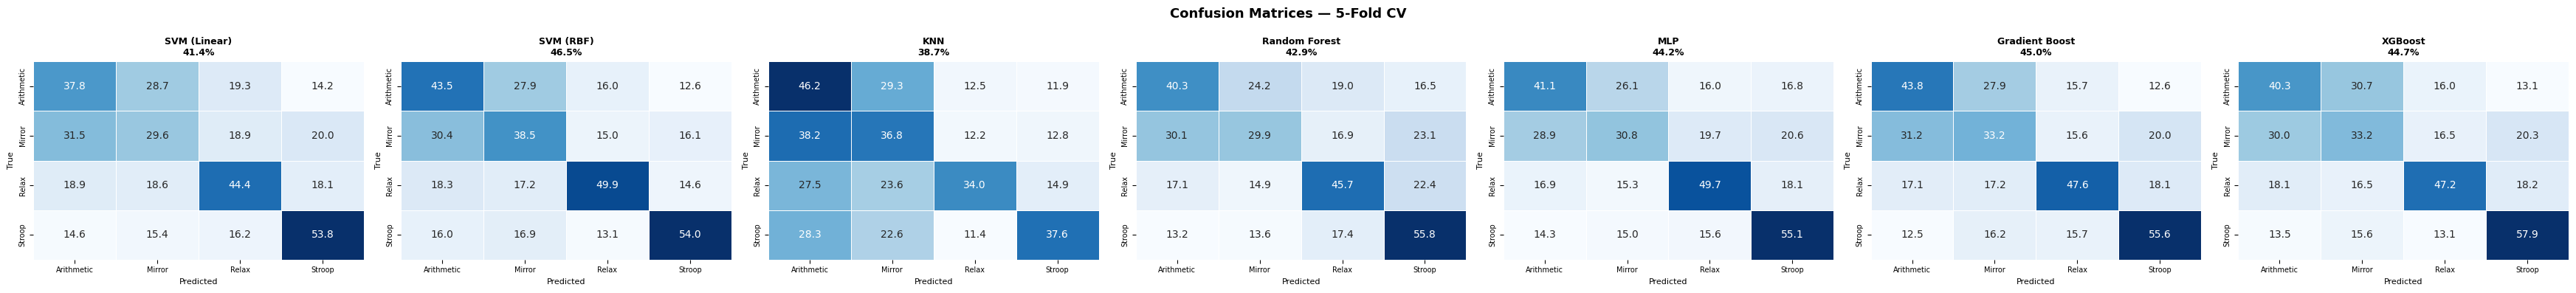

✅ Saved → cm_5fold.png


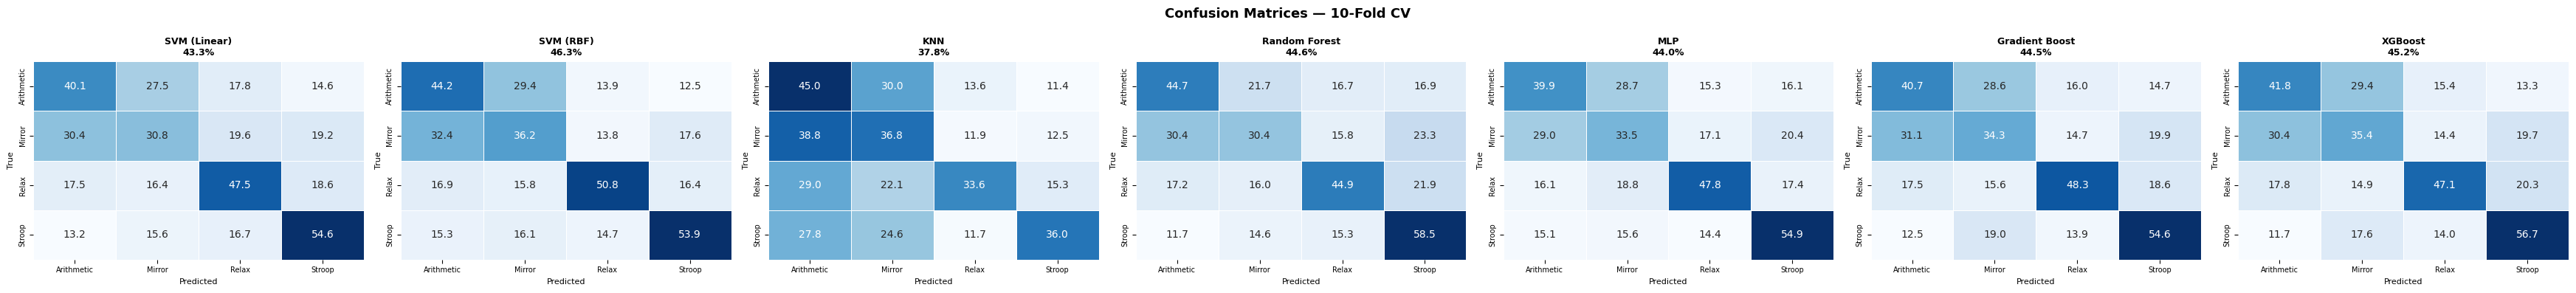

✅ Saved → cm_10fold.png


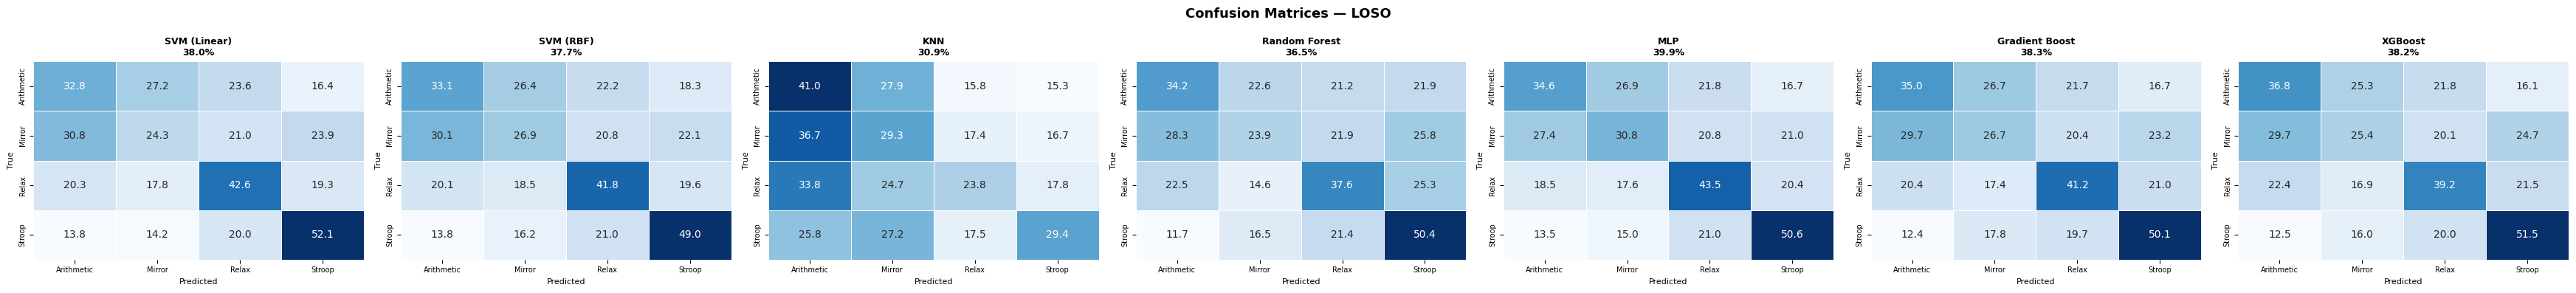

✅ Saved → cm_loso.png


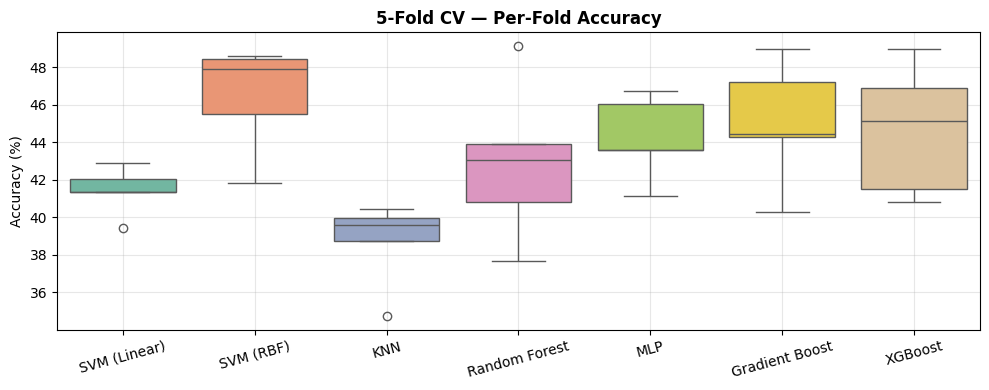

✅ Saved → boxplot_5fold.png


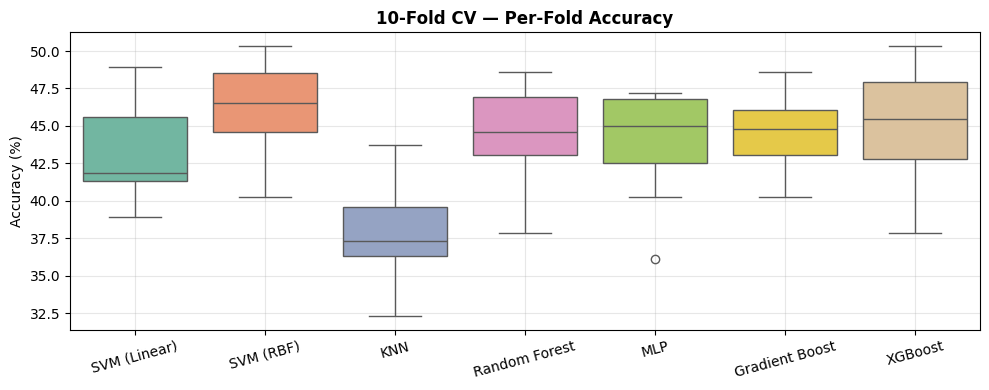

✅ Saved → boxplot_10fold.png


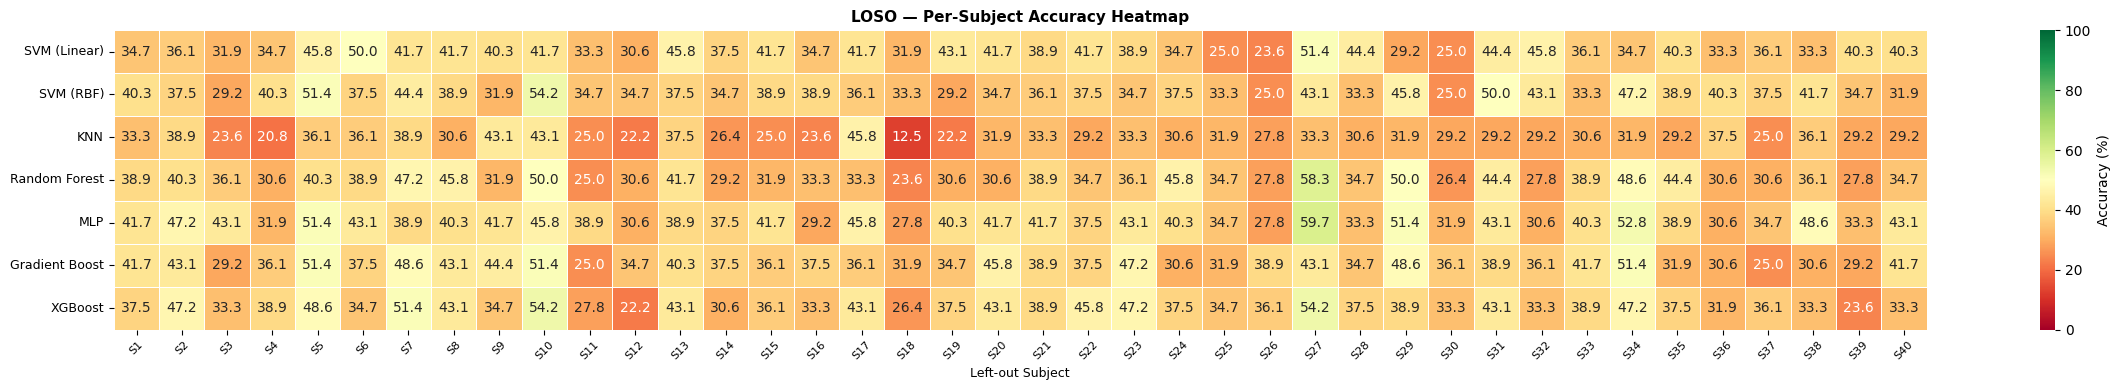

✅ Saved → loso_heatmap.png


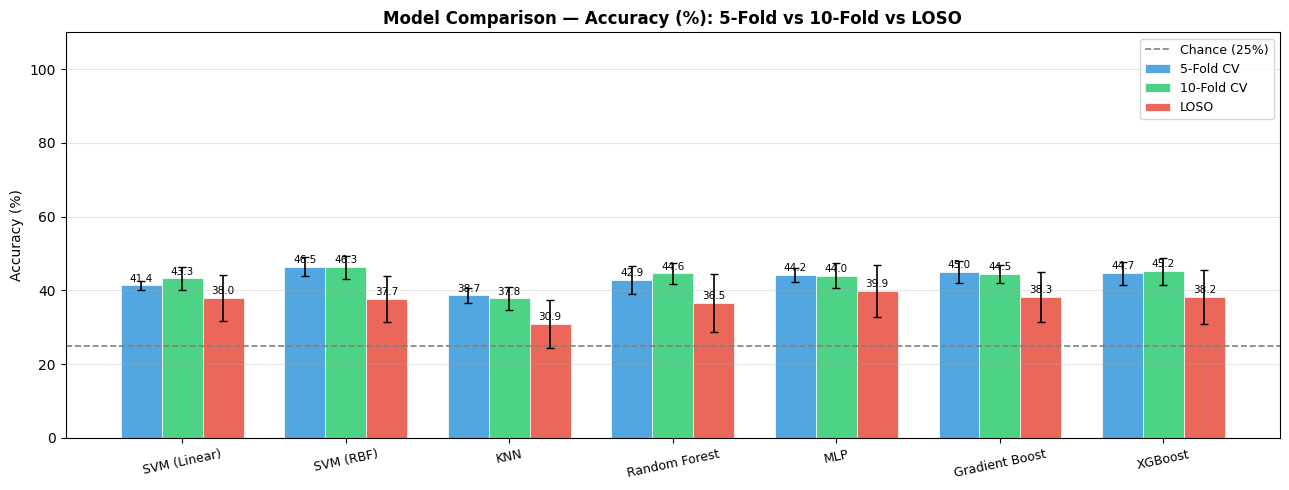

✅ Saved → comparison_accuracy.png


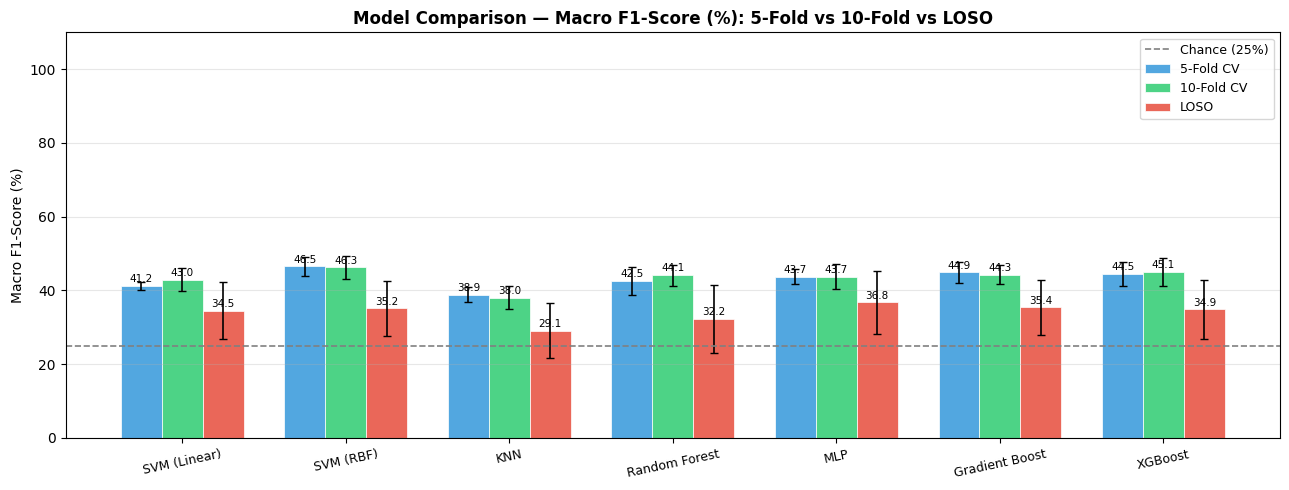

✅ Saved → comparison_f1.png


In [ ]:
# ── Helper: aggregate confusion matrix ───────────────────────────────────────
def plot_confusion_matrices(results_dict, title, fname):
    n = len(results_dict)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    if n == 1:
        axes = [axes]
    for ax, (name, folds) in zip(axes, results_dict.items()):
        cm_sum = sum(f['cm'] for f in folds).astype(float)
        cm_pct = cm_sum / cm_sum.sum(axis=1, keepdims=True) * 100
        sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                    xticklabels=TASK_NAMES, yticklabels=TASK_NAMES,
                    ax=ax, linewidths=0.5, cbar=False)
        acc = np.mean([f['accuracy'] for f in folds]) * 100
        ax.set_title(f"{name}\n{acc:.1f}%", fontsize=9, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=8)
        ax.set_ylabel('True', fontsize=8)
        ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {fname}")

# ── Plot confusion matrices for all three strategies ──────────────────────────
plot_confusion_matrices(kf5_results,   'Confusion Matrices — 5-Fold CV',   'cm_5fold.png')
plot_confusion_matrices(kf10_results,  'Confusion Matrices — 10-Fold CV',  'cm_10fold.png')
plot_confusion_matrices(loso_results,  'Confusion Matrices — LOSO',         'cm_loso.png')

# ── Per-fold accuracy boxplots ────────────────────────────────────────────────
def plot_boxplot(results_dict, title, fname):
    data = {name: [f['accuracy']*100 for f in folds]
            for name, folds in results_dict.items()}
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=pd.DataFrame(data), palette='Set2', ax=ax)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3)
    for tick in ax.get_xticklabels():
        tick.set_rotation(15)
    plt.tight_layout()
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {fname}")

plot_boxplot(kf5_results,  '5-Fold CV — Per-Fold Accuracy',  'boxplot_5fold.png')
plot_boxplot(kf10_results, '10-Fold CV — Per-Fold Accuracy', 'boxplot_10fold.png')

# ── LOSO: per-subject accuracy heatmap ───────────────────────────────────────
def plot_loso_heatmap(results, fname='loso_heatmap.png'):
    subjects = sorted({f['subject'] for folds in results.values() for f in folds})
    mat = np.full((len(MODEL_NAMES), len(subjects)), np.nan)
    for mi, name in enumerate(MODEL_NAMES):
        for fold in results[name]:
            si = subjects.index(fold['subject'])
            mat[mi, si] = fold['accuracy'] * 100
    fig, ax = plt.subplots(figsize=(max(10, len(subjects) * 0.6), 4))
    sns.heatmap(mat,
                xticklabels=[f'S{s}' for s in subjects],
                yticklabels=MODEL_NAMES,
                annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=0, vmax=100, linewidths=0.4,
                cbar_kws={'label': 'Accuracy (%)'},
                ax=ax)
    ax.set_title('LOSO — Per-Subject Accuracy Heatmap', fontsize=11, fontweight='bold')
    ax.set_xlabel('Left-out Subject', fontsize=9)
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {fname}")

plot_loso_heatmap(loso_results)

# ── Comparison bar chart: 5-Fold vs 10-Fold vs LOSO ──────────────────────────
def plot_comparison_bar(kf5_sum, kf10_sum, loso_sum, metric='acc',
                        label='Accuracy (%)', fname='comparison.png'):
    x = np.arange(len(MODEL_NAMES))
    w = 0.25
    fig, ax = plt.subplots(figsize=(13, 5))
    for i, (tag, summary, color) in enumerate([
            ('5-Fold CV',  kf5_sum,  '#3498DB'),
            ('10-Fold CV', kf10_sum, '#2ECC71'),
            ('LOSO',       loso_sum, '#E74C3C')]):
        means = np.array([np.mean(summary[m][metric]) * 100 for m in MODEL_NAMES])
        stds  = np.array([np.std(summary[m][metric])  * 100 for m in MODEL_NAMES])
        bars  = ax.bar(x + i*w, means, w, label=tag, color=color,
                       alpha=0.85, edgecolor='white', linewidth=0.6)
        ax.errorbar(x + i*w, means, yerr=stds, fmt='none',
                    color='black', capsize=3, lw=1.2)
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=7.5)
    ax.axhline(25, color='gray', ls='--', lw=1.2, label='Chance (25%)')
    ax.set_xticks(x + w)
    ax.set_xticklabels(MODEL_NAMES, rotation=12, fontsize=9)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'Model Comparison — {label}: 5-Fold vs 10-Fold vs LOSO',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 110)
    plt.tight_layout()
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {fname}")

plot_comparison_bar(kf5_summary, kf10_summary, loso_summary,
                    metric='acc', label='Accuracy (%)', fname='comparison_accuracy.png')
plot_comparison_bar(kf5_summary, kf10_summary, loso_summary,
                    metric='f1', label='Macro F1-Score (%)', fname='comparison_f1.png')


---
## 9 · Full Results Table

In [ ]:
rows = []
for method, summary in [('5-Fold', kf5_summary), ('10-Fold', kf10_summary), ('LOSO', loso_summary)]:
    for model, vals in summary.items():
        rows.append({
            'Method'    : method,
            'Model'     : model,
            'Acc_mean'  : np.mean(vals['acc']) * 100,
            'Acc_std'   : np.std(vals['acc'])  * 100,
            'F1_mean'   : np.mean(vals['f1'])  * 100,
            'F1_std'    : np.std(vals['f1'])   * 100,
            'Prec_mean' : np.mean(vals['precision']) * 100,
            'Rec_mean'  : np.mean(vals['recall'])    * 100,
        })

df_results = pd.DataFrame(rows).round(2)
df_results.to_csv('sam40_full_results.csv', index=False)
print("✅ Saved → sam40_full_results.csv\n")
print(df_results.to_string(index=False))

# ── Best model per strategy ───────────────────────────────────────────────────
print("\n" + "="*58)
print("  🏆  BEST MODEL PER VALIDATION STRATEGY")
print("="*58)
for method in ['5-Fold', '10-Fold', 'LOSO']:
    sub  = df_results[df_results['Method'] == method]
    best = sub.loc[sub['Acc_mean'].idxmax()]
    print(f"  {method:<10}: {best['Model']:<18}  "
          f"Acc={best['Acc_mean']:.2f}±{best['Acc_std']:.2f}%  "
          f"F1={best['F1_mean']:.2f}%")
print("="*58)


✅ Saved → sam40_full_results.csv

 Method          Model  Acc_mean  Acc_std  F1_mean  F1_std  Prec_mean  Rec_mean
 5-Fold   SVM (Linear)     41.39     1.14    41.20    1.14      41.11     41.39
 5-Fold      SVM (RBF)     46.46     2.57    46.52    2.54      46.78     46.46
 5-Fold            KNN     38.68     2.06    38.88    2.12      40.84     38.68
 5-Fold  Random Forest     42.92     3.79    42.50    3.75      42.52     42.92
 5-Fold            MLP     44.20     1.98    43.70    2.01      44.09     44.20
 5-Fold Gradient Boost     45.03     2.96    44.89    2.94      44.97     45.03
 5-Fold        XGBoost     44.65     3.12    44.52    3.18      44.59     44.65
10-Fold   SVM (Linear)     43.26     3.08    42.98    3.18      42.98     43.26
10-Fold      SVM (RBF)     46.28     3.14    46.27    3.21      46.64     46.28
10-Fold            KNN     37.85     3.02    38.00    3.10      40.00     37.85
10-Fold  Random Forest     44.62     2.96    44.12    2.82      44.34     44.62
10-Fol

---
## 10 · Hyperparameter Tuning

GridSearchCV on the best overall model (5-Fold accuracy). The fitted `BEST_MODEL` is ready for inference.

In [ ]:
import copy

PARAM_GRIDS = {
    'SVM (Linear)':   {'selector__k': [100, 150, 200], 'clf__C': [0.1, 0.5, 1.0]},
    'SVM (RBF)':      {'selector__k': [100, 150, 200], 'clf__C': [1, 5, 10, 20],
                        'clf__gamma': ['scale', 'auto']},
    'KNN':            {'selector__k': [100, 150], 'clf__n_neighbors': [5, 7, 11]},
    'Random Forest':  {'selector__k': [150, 200], 'clf__n_estimators': [200, 300],
                        'clf__max_depth': [15, 20, None]},
    'MLP':            {'selector__k': [100, 150, 200],
                        'clf__hidden_layer_sizes': [(128, 64), (256, 128), (256, 128, 64)]},
    'Gradient Boost': {'selector__k': [100, 150], 'clf__n_estimators': [100, 200],
                        'clf__max_depth': [4, 5, 6]},
    'XGBoost':        {'selector__k': [100, 150], 'clf__n_estimators': [200, 300],
                        'clf__max_depth': [5, 6], 'clf__learning_rate': [0.05, 0.1]},
}

# Identify best model by 5-Fold mean accuracy
kf5_acc = {m: np.mean(kf5_summary[m]['acc']) for m in MODEL_NAMES}
best_name = max(kf5_acc, key=kf5_acc.get)
print(f"Best model by 5-Fold accuracy: {best_name} ({kf5_acc[best_name]*100:.2f}%)")
print("Tuning …")

if best_name in PARAM_GRIDS:
    gs = GridSearchCV(
        estimator  = copy.deepcopy(build_models()[best_name]),
        param_grid = PARAM_GRIDS[best_name],
        cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring    = 'accuracy',
        n_jobs     = -1,
        verbose    = 1,
    )
    gs.fit(X_feat, y_epochs)
    print(f"\n✅ Best params : {gs.best_params_}")
    print(f"   Best CV acc : {gs.best_score_*100:.2f}%")
    BEST_MODEL = gs.best_estimator_
else:
    print(f"No grid defined for {best_name} — using default")
    BEST_MODEL = copy.deepcopy(build_models()[best_name])
    BEST_MODEL.fit(X_feat, y_epochs)
    print("✅ Model trained on full dataset")

print("\n🏁 BEST_MODEL is ready for inference.")


Best model by 5-Fold accuracy: SVM (RBF) (46.46%)
Tuning …
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best params : {'clf__C': 10, 'clf__gamma': 'scale', 'selector__k': 200}
   Best CV acc : 47.74%

🏁 BEST_MODEL is ready for inference.


---
## 11 · Save & Quick Inference Example

In [ ]:
import joblib

joblib.dump(BEST_MODEL, 'sam40_best_model.pkl')
print("✅ Model saved → sam40_best_model.pkl")

# ── Quick inference on one test epoch ─────────────────────────────────────────
sample_epoch = X_epochs[0]                           # (512, n_channels)
sample_feat  = extract_features(sample_epoch).reshape(1, -1)
prediction   = BEST_MODEL.predict(sample_feat)[0]
print(f"\nExample prediction: {TASK_NAMES[prediction]}")
print("(True label)      :", TASK_NAMES[y_epochs[0]])


✅ Model saved → sam40_best_model.pkl

Example prediction: Arithmetic
(True label)      : Arithmetic


---
## Summary

| Stage | Details |
|---|---|
| Dataset | SAM40 — 4 mental tasks, 128 Hz, 32 channels |
| Preprocessing | Bandpass 0.5–45 Hz → 50 Hz notch → z-norm |
| Epoching | 4-second non-overlapping windows |
| Features | Band power, DE, Hjorth, ratios, stats, correlation, FAA |
| Feature selection | Top 150 by ANOVA F-score (tuned in grid search) |
| Models | SVM ×2, KNN, RF, MLP, GradBoost, XGBoost |
| Validation | 5-Fold, 10-Fold, LOSO (subject-wise) |
| Output | `sam40_full_results.csv`, `sam40_best_model.pkl`, PNG plots |

> **Note on accuracy:** LOSO results are the most realistic estimate — K-fold scores will be higher because epochs from the same subject can appear in both train and test sets.
